# rBergomi Deep Calibration

Phase 1 ML capstone. Train a neural network to approximate the rBergomi forward map
$(H, \eta, \rho, v_0) \mapsto$ IV surface, using the certified Monte Carlo pricer as
ground truth. Calibration then becomes gradient descent on the network's *inputs* against
a target surface, milliseconds instead of slow-MC-per-evaluation.

Discipline: the pricer is ground truth, the network imitates the pricer, and we validate
the network against the pricer, never against the market. Market calibration is a separate,
later step. The network is a fast approximator on a certified baseline, not a black-box
predictor of a low-signal quantity.

Pipeline (all in `calibration/deep_cal/`): `surface.py` (params to surface), `dataset.py`
(generator), `network.py` (the MLP), `train.py` (training + node weighting + checkpoint),
`calibrate.py` (frozen-network input optimisation).

## Setup

Run from the repo root so relative `artifacts/` paths resolve. The `os.chdir("..")` hops up
from `notebooks/`; run it once (re-running keeps climbing, so restart the kernel if you do).

In [1]:
import os
os.chdir("..")            # notebooks/ -> repo root
print("cwd:", os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt

from calibration.deep_cal.surface import (
    rbergomi_iv_surface, MATURITIES, LOG_MONEYNESS, SURFACE_SHAPE,
)
from calibration.deep_cal.train import train, load_dataset, Scaler
from calibration.deep_cal.network import SurfaceNet
from calibration.deep_cal.calibrate import calibrate

cwd: D:\GitHub\quant-project


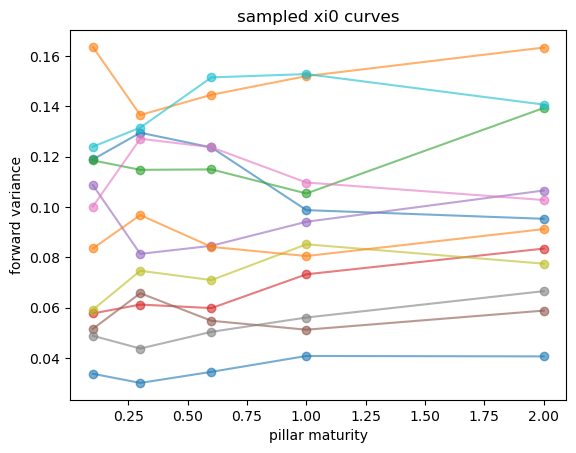

In [2]:
from calibration.deep_cal.dataset import sample_params
from calibration.deep_cal.surface import XI0_PILLARS

P = sample_params(12, np.random.default_rng(0))[:, 3:]   # 12 curves, pillar columns only
for row in P:
    plt.plot(XI0_PILLARS, row, marker="o", alpha=0.6)
plt.xlabel("pillar maturity")
plt.ylabel("forward variance")
plt.title("sampled xi0 curves")
plt.show()

In [3]:
import numpy as np
d = np.load("artifacts/rbergomi_termstructure_dataset.npz", allow_pickle=True)
print("surfaces:", d["surfaces"].shape)      # expect (4000, 8, 11)
print("params:", d["params"].shape)          # expect (4000, 8)
print("reject rate:", float(d["reject_rate"]))
print("param names:", d["param_names"])
print("any NaN in surfaces:", np.isnan(d["surfaces"]).any())

surfaces: (4000, 8, 11)
params: (4000, 8)
reject rate: 0.0
param names: ['H' 'eta' 'rho' 'xi0_0' 'xi0_1' 'xi0_2' 'xi0_3' 'xi0_4']
any NaN in surfaces: False


## 1. Per-node MC noise (measured, not guessed)

Hold the parameters fixed and simulate the surface with 30 different seeds. The std across
seeds at each node is the pure Monte Carlo noise, with the signal held constant. This drives
two decisions: which nodes to drop (informationless), and how to weight the rest
(inverse-noise). Expect the short-maturity deep wings to be far noisier than the interior,
and at least one node to floor to ~0 (a dead node the inversion returns as a constant).

In [4]:
from calibration.deep_cal.surface import rbergomi_iv_surface, XI0_PILLARS
# a representative interior curve: mid-level, gentle shape
pillars = np.full(len(XI0_PILLARS), 0.04)      # flat-ish mid curve for the noise probe
stack = np.array([rbergomi_iv_surface(0.11, 1.8, -0.7, pillars, n_paths=30_000,
                  rng=np.random.default_rng(s)) for s in range(30)])
noise = stack.std(axis=0)
np.save("artifacts/node_noise_ts.npy", noise)
print("worst noise node:", np.unravel_index(np.argmax(noise), noise.shape), noise.max().round(4))

worst noise node: (np.int64(1), np.int64(10)) 0.099


### Visualise the noise field

A heatmap makes the structure obvious: a clean interior and a few hot nodes in the
short-maturity wings. Those hot nodes are what the training weighting and the validity
mask exist to handle.

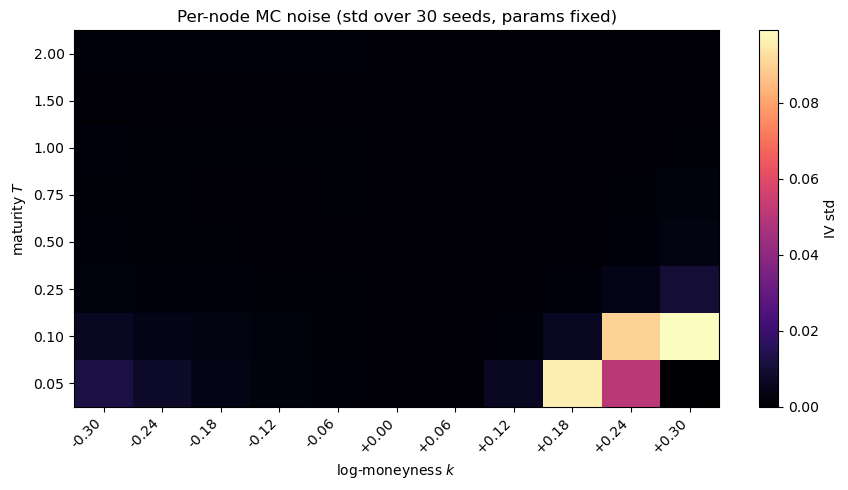

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(noise, aspect="auto", origin="lower", cmap="magma")
ax.set_xticks(range(len(LOG_MONEYNESS)))
ax.set_xticklabels([f"{k:+.2f}" for k in LOG_MONEYNESS], rotation=45, ha="right")
ax.set_yticks(range(len(MATURITIES)))
ax.set_yticklabels([f"{T:.2f}" for T in MATURITIES])
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("maturity $T$")
ax.set_title("Per-node MC noise (std over 30 seeds, params fixed)")
fig.colorbar(im, label="IV std")
fig.tight_layout()
plt.show()

## 2. Train the network

`train` splits before fitting scalers (no val leakage), standardises inputs and outputs,
drops nodes noisier than `noise_max`, and weights the survivors by inverse noise **in
standardised target units** (so the loss is well scaled). Early stopping on val loss.

The scalers, the validity mask, and the node weights are all saved in the checkpoint,
because calibration must apply the identical transform and mask at inference.

Sanity check on the very first line: epoch-0 train loss should be order 1, not hundreds.
A loss in the hundreds means the weights are in the wrong units (raw-IV noise applied to
standardised residuals).

In [6]:
noise = np.load("artifacts/node_noise_ts.npy")
res = train(dataset_name="rbergomi_termstructure_dataset.npz",
            checkpoint_name="surfacenet_ts.pt",
            noise=noise, epochs=2000, seed=0)
print("RMSE:", round(res["rmse_vol"],5), " max node err:", round(res["max_err"],5))

kept 83/88 nodes
weight min/mean/max: 0.19 / 1.00 / 1.77
epoch    0  train 8.499e+02  val 1.591e+02
epoch   50  train 1.813e+01  val 3.203e+00
epoch  100  train 1.557e+01  val 2.742e+00
epoch  150  train 1.466e+01  val 2.601e+00
epoch  200  train 1.391e+01  val 2.481e+00
epoch  250  train 1.341e+01  val 2.405e+00
epoch  300  train 1.317e+01  val 2.381e+00
epoch  350  train 1.289e+01  val 2.344e+00
epoch  400  train 1.251e+01  val 2.291e+00
epoch  450  train 1.209e+01  val 2.224e+00
epoch  500  train 1.185e+01  val 2.199e+00
epoch  550  train 1.164e+01  val 2.175e+00
epoch  600  train 1.156e+01  val 2.171e+00
epoch  650  train 1.137e+01  val 2.142e+00
epoch  700  train 1.143e+01  val 2.178e+00
epoch  750  train 1.121e+01  val 2.141e+00
early stop at epoch 783, best val 2.137e+00

held-out surface RMSE: 0.00860 vol pts   max node err: 0.36477  (valid nodes)
saved checkpoint to D:\GitHub\quant-project\artifacts\surfacenet_ts.pt
RMSE: 0.0086  max node err: 0.36477


### Training curves

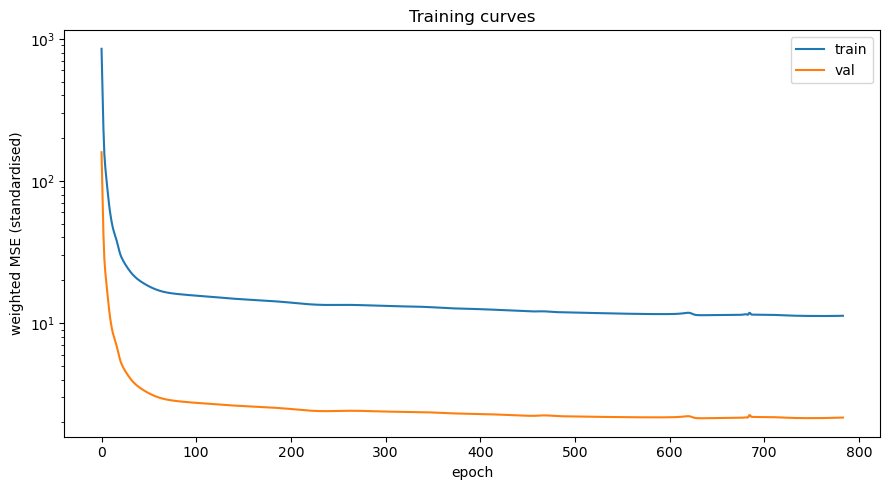

In [7]:
h = res["history"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h["train"], label="train")
ax.plot(h["val"], label="val")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("weighted MSE (standardised)")
ax.set_title("Training curves")
ax.legend()
fig.tight_layout()
plt.show()

### Worst surviving node

A good average can hide one bad node, so find the worst-fit valid node explicitly. If the
weighting and mask are working, the max error should be a small multiple of the RMSE, not
the ~30x seen when a noisy wing node was dragging the fit.

In [8]:
pred_iv, true_iv, valid = res["pred_iv"], res["true_iv"], res["valid_nodes"]
node_err = np.abs(pred_iv - true_iv).max(axis=0)
node_err[~valid] = 0.0
i = int(np.argmax(node_err))
print("worst valid node", np.unravel_index(i, SURFACE_SHAPE),
      "err", round(float(node_err[i]), 4))
print("dropped nodes:", [tuple(np.unravel_index(j, SURFACE_SHAPE)) for j in np.where(~valid)[0]])

worst valid node (np.int64(0), np.int64(0)) err 0.3648
dropped nodes: [(np.int64(0), np.int64(8)), (np.int64(0), np.int64(9)), (np.int64(0), np.int64(10)), (np.int64(1), np.int64(9)), (np.int64(1), np.int64(10))]


## 3. Synthetic recovery (the certification)

The real test of the whole pipeline: make a surface from KNOWN parameters, calibrate through
the frozen network, and check the parameters come back. Draw the target from the interior of
the trained box (not the edge, so we test accuracy not extrapolation), and price it with more
paths than training so the target is clean.

H is the identifiable parameter (the term-structure slope pins it), so it is the sharpest
check. eta and v0 trade off somewhat, so lean on the overall surface RMSE for those.

In [9]:
H_true, eta_true, rho_true = 0.11, 1.8, -0.7
pillars_true = np.array([0.035, 0.038, 0.040, 0.042, 0.045])   # gently rising curve

target = rbergomi_iv_surface(H_true, eta_true, rho_true, pillars_true,
                             n_paths=100_000, rng=np.random.default_rng(99))

out = calibrate(target, steps=800)

print("scalars recovered:", np.round(out["scalars"], 4),
      " true:", [H_true, eta_true, rho_true])
print("pillars recovered:", np.round(out["pillars"], 4))
print("pillars true:     ", pillars_true)
print("in box:", out["in_box"], " surface RMSE:", round(out["surface_rmse"], 5))

scalars recovered: [ 0.1082  1.8396 -0.6862]  true: [0.11, 1.8, -0.7]
pillars recovered: [0.0352 0.0387 0.0401 0.0404 0.047 ]
pillars true:      [0.035 0.038 0.04  0.042 0.045]
in box: True  surface RMSE: 0.00215


### Recovery readout

If H comes back within a few thousandths and the surface RMSE is small, the pipeline is
certified end to end: params in, surface out, calibrate, params back. This is the deep-cal
analogue of the ground-truth recovery tests used throughout Phase 1.

In [10]:
pred_iv, true_iv, valid = res["pred_iv"], res["true_iv"], res["valid_nodes"]
node_err = np.abs(pred_iv - true_iv).max(axis=0)
node_err[~valid] = 0.0
order = np.argsort(node_err)[::-1][:5]      # top 5 worst
for i in order:
    print(np.unravel_index(i, (8,11)), "err", round(float(node_err[i]),3),
          "noise", round(float(noise.reshape(-1)[i]),4))

(np.int64(0), np.int64(0)) err 0.365 noise 0.012
(np.int64(0), np.int64(1)) err 0.299 noise 0.008
(np.int64(1), np.int64(0)) err 0.196 noise 0.0064
(np.int64(1), np.int64(1)) err 0.177 noise 0.0046
(np.int64(0), np.int64(2)) err 0.166 noise 0.0041


## SPX data reading



In [4]:
from calibration.deep_cal.spx_data import load_spx_surface
from data.option_chain import fetch_chain_cboe

all_options, spot = fetch_chain_cboe("^SPX")
r = 0.045   # your FRED short rate, hardcoded as in Phase 1

mkt = load_spx_surface(all_options, spot=spot, r=r)

vld = mkt["market_valid"]
print("nodes market-valid:", int(vld.sum()), "/ 88")
print("valid per maturity:", vld.sum(axis=1), "(out of 11)")
print("forwards:", [round(f,1) if f==f else None for f in mkt["forwards"]])
print("dtes:    ", [int(d) if d==d else None for d in mkt["dtes"]])

nodes market-valid: 43 / 88
valid per maturity: [ 0  7  8  9  9 10  0  0] (out of 11)
forwards: [None, np.float64(7692.1), np.float64(7733.1), np.float64(7813.5), np.float64(7896.0), np.float64(7981.6), None, None]
dtes:     [None, 35, 91, 182, 272, 364, None, None]


In [7]:
# out = calibrate(mkt["surface"], checkpoint_name="surfacenet_ts.pt",
#                 market_valid=mkt["market_valid"], steps=800)
print("scalars:", np.round(out["scalars"], 4))
print("pillars:", np.round(out["pillars"], 4))
print("pinned:", np.round(out["pinned"], 4))
print("n_nodes:", out["n_nodes"])
print("surface RMSE (valid nodes):", round(out["surface_rmse"], 5))

scalars: [ 0.1073  2.4594 -0.8959]
pillars: [0.0238 0.0542 0.0451 0.0762 0.0152]
pinned: []
n_nodes: 43
surface RMSE (valid nodes): 0.00673


C:\Users\U-ser\AppData\Local\Temp\ipykernel_38832\2721593770.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,0].legend()


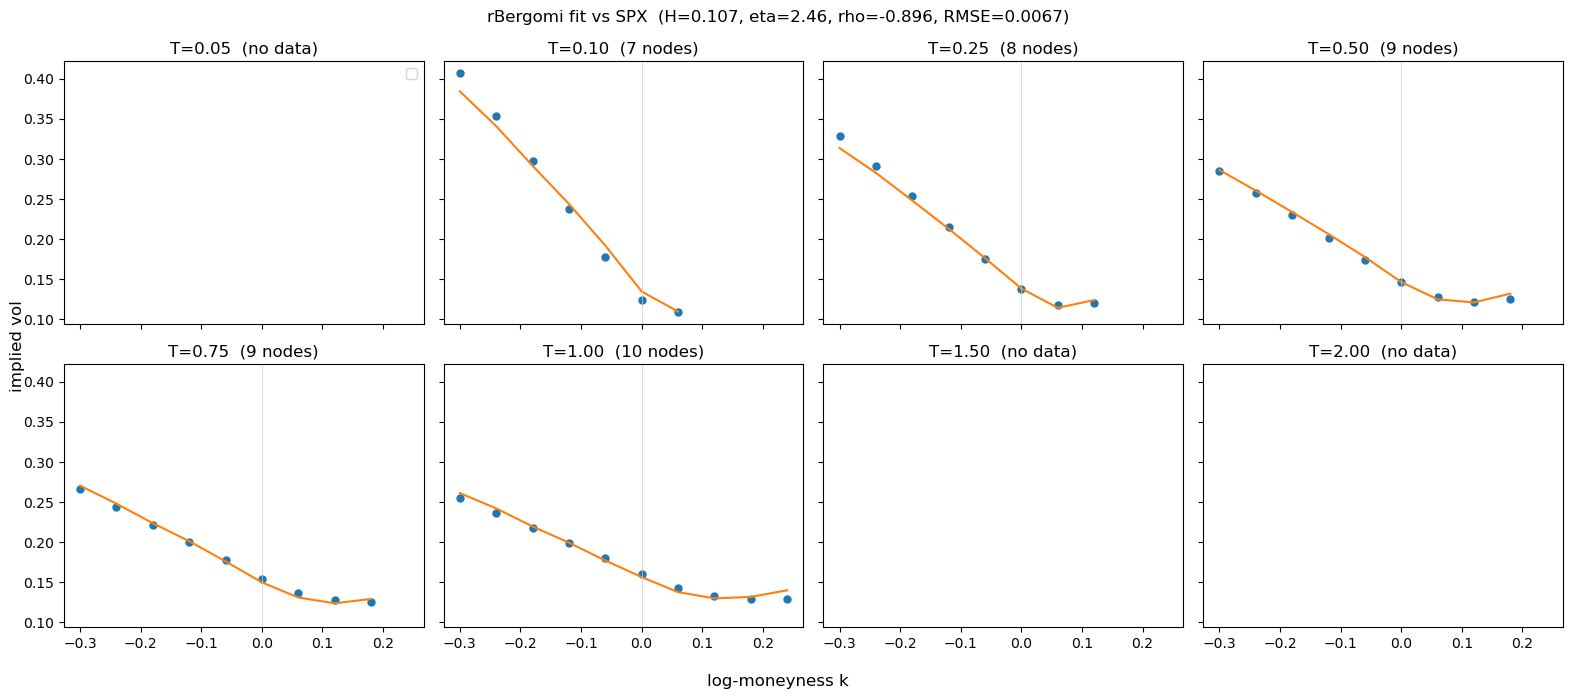

In [8]:
import torch, numpy as np
import matplotlib.pyplot as plt
from calibration.deep_cal.calibrate import load_model
from calibration.deep_cal.surface import MATURITIES, LOG_MONEYNESS

net, ckpt = load_model("surfacenet_ts.pt"); net = net.double()
xm = np.asarray(ckpt["x_mean"]); xs = np.asarray(ckpt["x_std"])
ym = np.asarray(ckpt["y_mean"]); ysd = np.asarray(ckpt["y_std"])

theta = out["theta"]
with torch.no_grad():
    tn = (torch.tensor(theta) - torch.tensor(xm)) / torch.tensor(xs)
    fit = (net(tn.unsqueeze(0)).squeeze(0) * torch.tensor(ysd) + torch.tensor(ym)).numpy()
fit = fit.reshape(8, 11)

mv = mkt["market_valid"]
mkt_surf = mkt["surface"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    m = mv[i]
    if m.sum() == 0:
        ax.set_title(f"T={MATURITIES[i]:.2f}  (no data)"); continue
    ax.plot(LOG_MONEYNESS[m], mkt_surf[i][m], "o", label="market", ms=5)
    ax.plot(LOG_MONEYNESS[m], fit[i][m], "-", label="rBergomi fit")
    ax.set_title(f"T={MATURITIES[i]:.2f}  ({int(m.sum())} nodes)")
    ax.axvline(0, color="0.8", lw=0.5)
axes[0,0].legend()
fig.supxlabel("log-moneyness k"); fig.supylabel("implied vol")
fig.suptitle(f"rBergomi fit vs SPX  (H={theta[0]:.3f}, eta={theta[1]:.2f}, rho={theta[2]:.3f}, RMSE={out['surface_rmse']:.4f})")
fig.tight_layout(); plt.show()

## Lesson: what deep calibration is, and what this notebook actually did

### The problem it solves
Calibrating rBergomi the classical way means an optimiser that calls the Monte Carlo pricer
hundreds of times per fit, each call a full simulation. That is minutes to hours for one
surface, far too slow to be practical. Deep calibration (Horvath, Muguruza, Tomas 2019)
replaces the slow inner loop with a neural network trained ONCE, offline, to imitate the
pricer. Calibration then becomes gradient descent on the network's inputs, milliseconds with
exact gradients.

The discipline that keeps this honest: the network never predicts the market. It approximates
a function we already have exactly, the certified MC pricer. We train it against the pricer,
validate it against the pricer, and only at the very end point the finished machine at real
data. The network is a fast approximator on a certified baseline, not a black-box predictor.

### The pipeline, in five pieces
1. `surface.py` maps parameters $(H, \eta, \rho, \xi_0)$ to an IV surface on a fixed grid,
   using the MC pricer. This is the ground truth the network learns.
2. `dataset.py` samples thousands of parameter sets and prices their surfaces offline. This is
   where all the MC cost goes, once.
3. `network.py` is a small MLP: parameters in, the whole flattened surface out.
4. `train.py` fits the network to the dataset, and crucially saves the input/output scalers,
   the node-validity mask, and the node weights IN the checkpoint, because inference must apply
   the identical transforms.
5. `calibrate.py` freezes the network and does gradient descent on its INPUTS to match a target
   surface. The network is differentiable, so the parameter gradients are exact.

### Why the forward-variance curve had to become a curve
The first version used a flat $\xi_0 = v_0$, a single variance level. That certified the pipeline
on synthetic recovery, but it can never fit a real SPX surface, whose variance term structure
slopes and kinks with the VIX curve. A flat $\xi_0$ gives the network no lever to match the level
of IV at each maturity, so it would force the shape parameters to compensate and mis-recover
everything. So we widened $\xi_0$ to a set of forward-variance pillars, sampled as a base level
plus smooth correlated perturbations, so the network learns realistic curve shapes rather than
the wild non-monotonic curves independent sampling would produce.

### The debugging lessons 
Most of the work was not writing the pipeline, it was making it actually behave. Each of these
cost real time and each is a general lesson.

- **Measure noise, do not guess it.** The network could not fit the short-dated wings, and the
  fix was not more training. Holding parameters fixed and simulating with many seeds isolates the
  pure MC noise per node from the real signal. That measurement drove which nodes to drop
  (informationless) and how to weight the rest (inverse-noise). Noise and approximability are
  separate axes: the noisy corner (short-dated calls, unstable inversion) and the hard-to-fit
  corner (short-dated puts, steepest curvature) were different corners.

- **Weighting has both a scale and a range.** Inverse-variance weights spanned 84x, so a few
  clean nodes dominated the loss and the network ignored everything else. Normalising the mean to
  1 does nothing to the range; you have to clip it. And the weights must live in the same units as
  the residuals they multiply (standardised space here), or the loss scale is meaningless.

- **A zero weight does not neutralise a NaN.** $0 \times \text{NaN} = \text{NaN}$, which flows
  through backprop into every parameter. Failed maturity rows left NaN in the target, and masking
  them with zero weight was not enough, the NaN had to be replaced with a finite dummy value
  first. Masking and sanitising are two separate, both-required steps.

- **Calibrate on exactly the nodes the network learned.** When the network was trained on a
  subset of nodes but calibration scored all of them uniformly, the excluded nodes dragged the
  fit and parameter recovery regressed. The training mask and the calibration objective must
  agree.

- **Constrain the optimisation to the trained box.** Unconstrained gradient descent on the
  network inputs walked the parameters clean out of their valid ranges (correlation below -1, a
  negative variance) and still got a low RMSE, because outside its training domain the network is
  an arbitrary smooth extrapolator, not rBergomi. The fix is to optimise in an unconstrained
  space mapped into the box by a sigmoid, so every proposed parameter is valid by construction.
  A parameter that then pins to a box edge is a real signal (the surface straining the model), not
  an artifact.

### What the real fit showed
On live SPX the calibration returned $H \approx 0.11$, $\rho \approx -0.90$, $\eta \approx 2.5$,
all economically sane and none pinned to a box edge, with a surface RMSE under one vol point. The
per-maturity plot fits the interior and long maturities almost exactly. The one honest limitation
is the short-dated deep-put wing, where the market skew is slightly steeper than a single-$H$
rBergomi can bend to. That undershoot is a structural signature of the model, not a calibration
error, and it points at where a richer model (multi-factor or rough-Heston) would earn its keep.

### The transferable idea
The pattern here generalises well beyond rBergomi: when a model is expensive to evaluate but you
have a certified evaluator, train a fast differentiable approximator against that evaluator,
validate the approximator against it, and calibrate through the approximator under constraints
that keep it inside its trained domain. The certified baseline is what makes the speed-up
trustworthy rather than a black box.

There is a second, related move worth naming, which I used during my placement at Malvern
Panalytical: using a mathematical and stochastic simulation of the end result, together with
machine learning, to manufacture large volumes of data that would otherwise be prohibitively
expensive to obtain in time and money, and then using that synthetic data to build further models
and innovations downstream. This notebook is a small instance of the same idea, the MC pricer
generates thousands of surfaces that no real market could supply, and the network is trained on
that synthetic corpus. The broader lesson is that a trustworthy simulator is not only a validation
tool, it is a data generator: once you can simulate ground truth cheaply and correctly, you can
produce training sets at a scale reality never offers, and that unlocks models that would be
impossible to fit on real data alone.

Recognising that the same skeleton (a trusted forward model, a fast learned stand-in, validation
against the reference rather than the noisy target) recurs across completely unrelated domains is
the real point. It is a general strategy for any problem where evaluation or data collection is
the bottleneck and a reliable reference exists.